# Notebook 5 — Peer Comparison Engine
For any given company, find its top 5 financial peers using cosine similarity on the feature matrix. Exports `data/peer_mapping.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120})

DATA = Path('../data/clean')
pl = pd.read_csv(DATA / 'profitandloss.csv')
bs = pd.read_csv(DATA / 'balancesheet.csv')
cf = pd.read_csv(DATA / 'cashflow.csv')
co = pd.read_csv(DATA / 'companies.csv')
an = pd.read_csv(DATA / 'analysis.csv')

pl = pl[pl['is_ttm'] == False]
bs = bs[bs['is_ttm'] == False]
cf = cf[cf['is_ttm'] == False]
print('Data loaded.')

Data loaded.


## Step 1 — Build feature matrix (same as Notebook 4)

In [2]:
avg_pl = pl.groupby('company_id').agg(
    avg_opm=('opm_percentage','mean'), avg_npm=('net_profit_margin_pct','mean'),
    avg_div=('dividend_payout','mean'), avg_ic=('interest_coverage','mean')
).reset_index()
avg_bs = bs.groupby('company_id').agg(
    avg_de=('debt_to_equity','mean'), avg_eqr=('equity_ratio','mean')
).reset_index()
avg_cf = cf.groupby('company_id').agg(
    avg_ocf=('operating_activity','mean'), avg_fcf=('free_cash_flow','mean')
).reset_index()
an3 = an[an['period']=='3Y'][['company_id','compounded_sales_growth_pct']].rename(
    columns={'compounded_sales_growth_pct':'growth_3y'})
roe_df = co[['symbol','roe_percentage']].rename(columns={'symbol':'company_id'})

feats = avg_pl.merge(avg_bs,on='company_id',how='outer')
feats = feats.merge(avg_cf,on='company_id',how='outer')
feats = feats.merge(an3,on='company_id',how='left')
feats = feats.merge(roe_df,on='company_id',how='left')
feats = feats.set_index('company_id').fillna(feats.median(numeric_only=True))

scaler = StandardScaler()
X = scaler.fit_transform(feats)
print(f'Feature matrix: {X.shape}')

Feature matrix: (101, 10)


## Step 2 — Compute cosine similarity matrix

In [3]:
sim_matrix = cosine_similarity(X)
sim_df = pd.DataFrame(sim_matrix, index=feats.index, columns=feats.index)
print(f'Similarity matrix: {sim_df.shape}')
print('\nSample: TCS similarity to others (top 10):')
if 'TCS' in sim_df.index:
    print(sim_df['TCS'].sort_values(ascending=False).head(10))

Similarity matrix: (101, 101)

Sample: TCS similarity to others (top 10):
company_id
TCS           1.000000
HCLTECH       0.695607
VEDL          0.671396
SBIN          0.658550
ONGC          0.642637
ITC           0.632948
NTPC          0.551441
BHARTIARTL    0.534721
TECHM         0.519110
GAIL          0.516196
Name: TCS, dtype: float64


## Step 3 — Find top 5 peers for every company

In [4]:
peer_records = []
for sym in feats.index:
    peers = sim_df[sym].drop(sym).nlargest(5)
    for rank, (peer_sym, sim_score) in enumerate(peers.items(), 1):
        peer_records.append({'symbol': sym, 'peer_rank': rank,
                             'peer_symbol': peer_sym, 'similarity_score': round(sim_score, 4)})

peer_mapping = pd.DataFrame(peer_records)
print(f'Peer mappings generated: {len(peer_mapping)}')
print(peer_mapping[peer_mapping['symbol'] == 'TCS'].to_string(index=False))

Peer mappings generated: 505


symbol  peer_rank peer_symbol  similarity_score
   TCS          1     HCLTECH            0.6956
   TCS          2        VEDL            0.6714
   TCS          3        SBIN            0.6586
   TCS          4        ONGC            0.6426
   TCS          5         ITC            0.6329


## Step 4 — Validation: TCS peers should be IT companies

In [5]:
companies_map = co.set_index('symbol')['sector'].to_dict()
for test_sym in ['TCS', 'HDFCBANK', 'RELIANCE']:
    if test_sym not in peer_mapping['symbol'].values:
        print(f'{test_sym} not in data')
        continue
    peers = peer_mapping[peer_mapping['symbol'] == test_sym]
    peer_syms = peers['peer_symbol'].tolist()
    peer_sectors = [companies_map.get(p, 'Unknown') for p in peer_syms]
    print(f'\n{test_sym} ({companies_map.get(test_sym,"?")}) — top 5 peers:')
    for p, s, sc in zip(peer_syms, peer_sectors, peers['similarity_score'].tolist()):
        print(f'  {p:<15} ({s:<15}) similarity={sc:.4f}')


TCS (IT) — top 5 peers:
  HCLTECH         (IT             ) similarity=0.6956
  VEDL            (Unknown        ) similarity=0.6714
  SBIN            (Banking        ) similarity=0.6586
  ONGC            (Energy         ) similarity=0.6426
  ITC             (FMCG           ) similarity=0.6329

HDFCBANK (Banking) — top 5 peers:
  SBILIFE         (Insurance      ) similarity=0.6955
  HINDALCO        (Metals         ) similarity=0.1900
  INDUSINDBK      (Banking        ) similarity=0.1532
  AXISBANK        (Banking        ) similarity=0.1410
  COALINDIA       (Metals         ) similarity=0.1394

RELIANCE (Energy) — top 5 peers:
  ONGC            (Energy         ) similarity=0.8112
  NTPC            (Power          ) similarity=0.7602
  IOC             (Energy         ) similarity=0.6391
  BHARTIARTL      (Telecom        ) similarity=0.6081
  POWERGRID       (Power          ) similarity=0.5104


## Step 5 — Similarity heatmap for top 20 companies

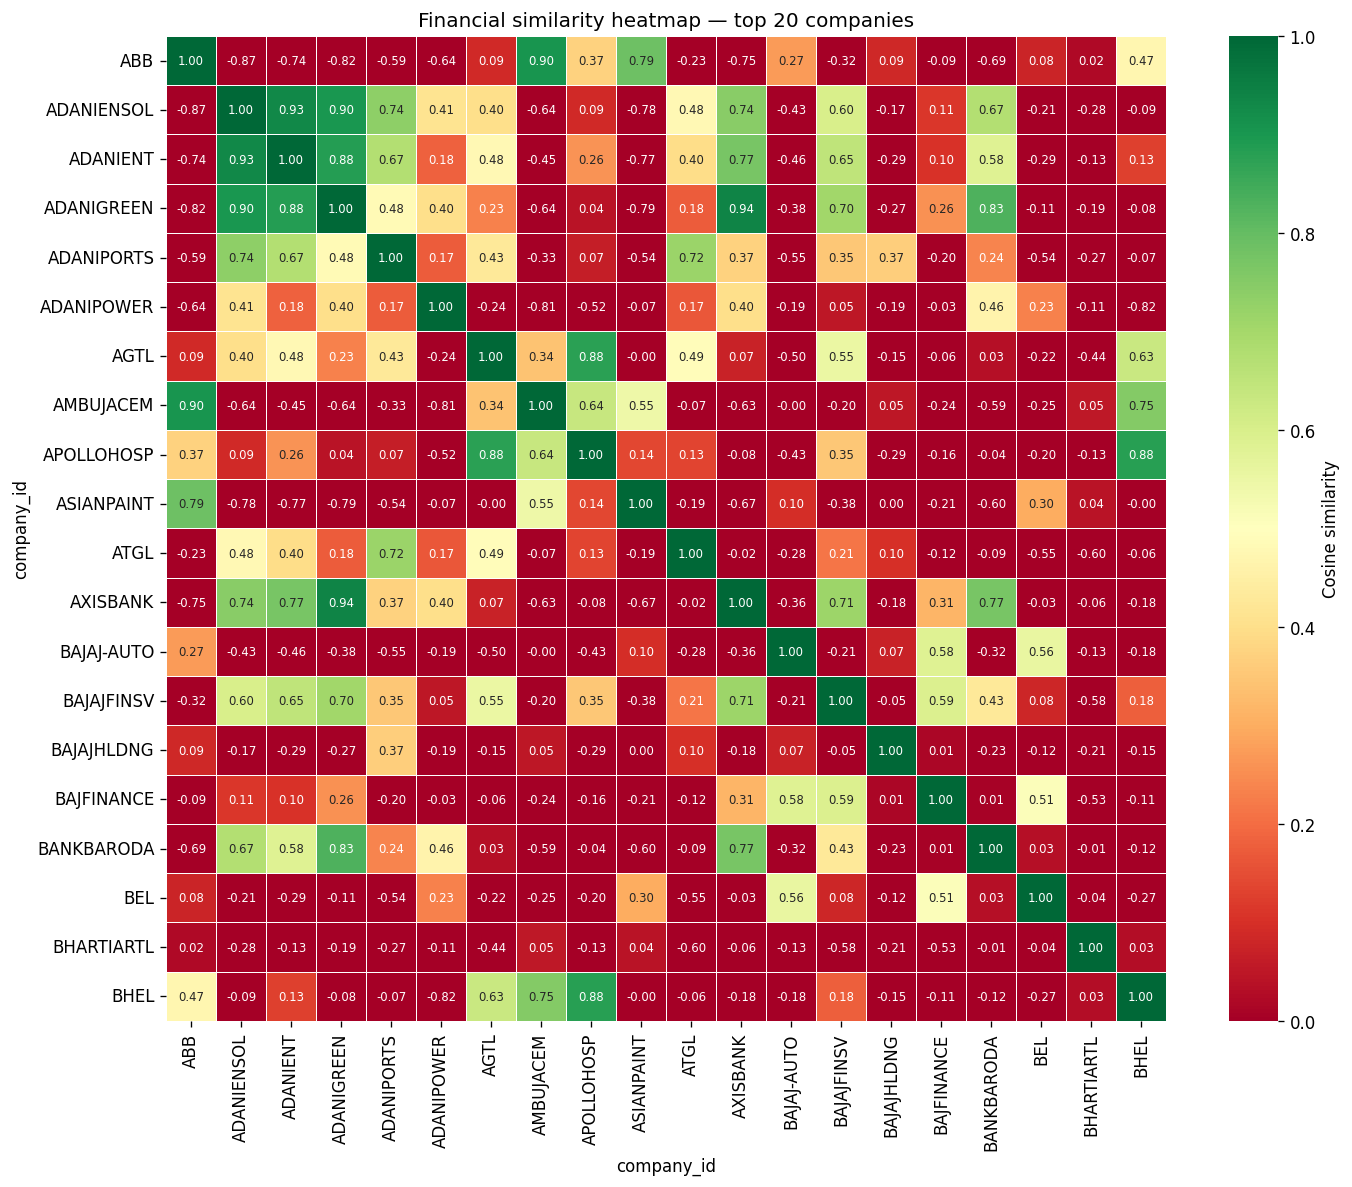

In [6]:
top20 = feats.index[:20].tolist()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_df.loc[top20, top20], cmap='RdYlGn', vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            linewidths=0.3, ax=ax, cbar_kws={'label': 'Cosine similarity'})
ax.set_title('Financial similarity heatmap — top 20 companies')
plt.tight_layout()
plt.show()

## Step 6 — Export peer_mapping.csv

In [7]:
peer_mapping.to_csv('../data/peer_mapping.csv', index=False)
print(f'Exported data/peer_mapping.csv — {len(peer_mapping)} rows')
print(peer_mapping.head(10).to_string(index=False))

Exported data/peer_mapping.csv — 505 rows
    symbol  peer_rank peer_symbol  similarity_score
       ABB          1       DABUR            0.9553
       ABB          2    BOSCHLTD            0.9126
       ABB          3        LTIM            0.9081
       ABB          4   AMBUJACEM            0.9036
       ABB          5       TECHM            0.8898
ADANIENSOL          1       LODHA            0.9548
ADANIENSOL          2    ADANIENT            0.9308
ADANIENSOL          3   TATAPOWER            0.9192
ADANIENSOL          4  ADANIGREEN            0.9007
ADANIENSOL          5    UNITDSPR            0.8789
